# Comparison Plotting Tests

Visual verification of `interpolate_to_grid`, `compute_difference`, and `ComparisonBuilder`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from kika.plotting import (
    PlotData,
    PlotBuilder,
    DifferencePlotData,
    ComparisonBuilder,
    ComparisonResult,
    compute_difference,
    interpolate_to_grid,
)

## 1. `interpolate_to_grid` — visual check

### 1.1 Identical grids (lin-lin)

In [2]:
x = np.array([1.0, 2.0, 3.0, 4.0])
y = np.array([10.0, 20.0, 30.0, 40.0])
result = interpolate_to_grid(x, x, y, method='lin-lin')
np.testing.assert_allclose(result, y)
print('PASS — identical grids return identical values')

PASS — identical grids return identical values


### 1.2 Log-log interpolation (power-law data)

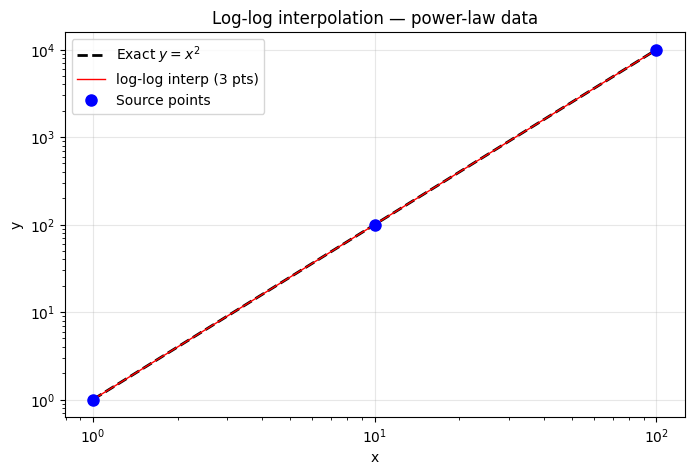

PASS — log-log interpolation exact for power-law


In [3]:
# y = x^2 is perfectly linear in log-log space
x_src = np.array([1.0, 10.0, 100.0])
y_src = x_src ** 2
x_tgt = np.logspace(0, 2, 200)

y_interp = interpolate_to_grid(x_tgt, x_src, y_src, method='log-log')

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(x_tgt, x_tgt**2, 'k--', lw=2, label='Exact $y = x^2$')
ax.loglog(x_tgt, y_interp, 'r-', lw=1, label='log-log interp (3 pts)')
ax.loglog(x_src, y_src, 'bo', ms=8, label='Source points')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Log-log interpolation — power-law data')
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

np.testing.assert_allclose(y_interp, x_tgt**2, rtol=1e-10)
print('PASS — log-log interpolation exact for power-law')

### 1.3 Out-of-range points → NaN

In [4]:
x_src = np.array([2.0, 4.0, 6.0])
y_src = np.array([10.0, 20.0, 30.0])
x_tgt = np.array([1.0, 3.0, 5.0, 7.0])

result = interpolate_to_grid(x_tgt, x_src, y_src, method='lin-lin')

assert np.isnan(result[0]), 'Below range should be NaN'
assert np.isnan(result[3]), 'Above range should be NaN'
assert np.isfinite(result[1]) and np.isfinite(result[2])
print(f'PASS — out-of-range → NaN: {result}')

PASS — out-of-range → NaN: [nan 15. 25. nan]


### 1.4 Non-positive y with log-y → graceful fallback

In [5]:
x_src = np.array([1.0, 2.0, 3.0])
y_src = np.array([-1.0, 0.0, 1.0])
x_tgt = np.array([1.5, 2.5])

# lin-log should fall back to linear y
result = interpolate_to_grid(x_tgt, x_src, y_src, method='lin-log')
np.testing.assert_allclose(result, [-0.5, 0.5], rtol=1e-10)
print(f'PASS — lin-log fallback: {result}')

# log-log should also not crash
result2 = interpolate_to_grid(x_tgt, x_src, y_src, method='log-log')
assert np.all(np.isfinite(result2))
print(f'PASS — log-log fallback (finite): {result2}')

PASS — lin-log fallback: [-0.5  0.5]
PASS — log-log fallback (finite): [-0.4150375   0.55033971]


### 1.5 All four interpolation methods compared

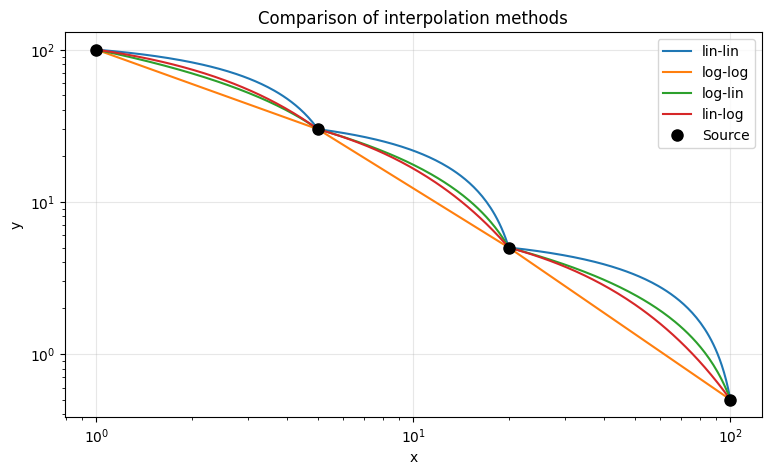

In [6]:
# Sparse source, dense target — compare methods visually
x_src = np.array([1.0, 5.0, 20.0, 100.0])
y_src = np.array([100.0, 30.0, 5.0, 0.5])
x_tgt = np.logspace(0, 2, 300)

methods = ['lin-lin', 'log-log', 'log-lin', 'lin-log']
fig, ax = plt.subplots(figsize=(9, 5))
for m in methods:
    y_i = interpolate_to_grid(x_tgt, x_src, y_src, method=m)
    ax.plot(x_tgt, y_i, label=m)
ax.plot(x_src, y_src, 'ko', ms=8, zorder=5, label='Source')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Comparison of interpolation methods')
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

---
## 2. `compute_difference` — numerical checks

### 2.1 Relative difference (percent)

In [7]:
ref = PlotData(x=np.array([1., 2., 3.]), y=np.array([10., 20., 30.]), label='ref')
cmp = PlotData(x=np.array([1., 2., 3.]), y=np.array([11., 22., 33.]), label='cmp')

result = compute_difference(ref, cmp, mode='relative', interpolation='lin-lin')

np.testing.assert_allclose(result.difference.y, [10., 10., 10.])
assert result.difference.difference_type == 'relative'
print(f'PASS — relative diff: {result.difference.y} %')
print(f'       auto-label: "{result.difference.label}"')

PASS — relative diff: [10. 10. 10.] %
       auto-label: "(cmp − ref) / ref"


### 2.2 Absolute difference

In [8]:
result_abs = compute_difference(ref, cmp, mode='absolute', interpolation='lin-lin')
np.testing.assert_allclose(result_abs.difference.y, [1., 2., 3.])
print(f'PASS — absolute diff: {result_abs.difference.y}')

PASS — absolute diff: [1. 2. 3.]


### 2.3 Zero reference → NaN (no division-by-zero)

In [9]:
ref_z = PlotData(x=np.array([1., 2., 3.]), y=np.array([0., 10., 20.]), label='ref')
cmp_z = PlotData(x=np.array([1., 2., 3.]), y=np.array([5., 15., 25.]), label='cmp')

result_z = compute_difference(ref_z, cmp_z, mode='relative', interpolation='lin-lin')
assert np.isnan(result_z.difference.y[0]), 'Zero-ref point must be NaN'
assert np.isfinite(result_z.difference.y[1])
print(f'PASS — zero reference handled: {result_z.difference.y}')

PASS — zero reference handled: [nan 50. 25.]


### 2.4 Non-overlapping ranges → ValueError

In [10]:
ref_no = PlotData(x=np.array([1., 2.]), y=np.array([10., 20.]), label='ref')
cmp_no = PlotData(x=np.array([5., 6.]), y=np.array([50., 60.]), label='cmp')

try:
    compute_difference(ref_no, cmp_no, interpolation='lin-lin')
    print('FAIL — should have raised ValueError')
except ValueError as e:
    print(f'PASS — non-overlapping raises ValueError: {e}')

PASS — non-overlapping raises ValueError: No overlapping x-range. Reference: [1.000000e+00, 2.000000e+00], Comparison: [5.000000e+00, 6.000000e+00]


### 2.5 Grid strategies

In [11]:
ref_g = PlotData(x=np.array([1., 2., 3.]), y=np.array([10., 20., 30.]), label='ref')
cmp_g = PlotData(x=np.array([1.5, 2.5]), y=np.array([15., 25.]), label='cmp')

# grid='reference' — keeps ref grid (only overlap region)
r1 = compute_difference(ref_g, cmp_g, grid='reference', interpolation='lin-lin')
print(f'reference grid: {r1.common_x}')
np.testing.assert_array_equal(r1.common_x, np.array([2.0]))

# grid='comparison' — keeps cmp grid
r2 = compute_difference(ref_g, cmp_g, grid='comparison', interpolation='lin-lin')
print(f'comparison grid: {r2.common_x}')
np.testing.assert_array_equal(r2.common_x, np.array([1.5, 2.5]))

# grid='union' — merged
r3 = compute_difference(ref_g, cmp_g, grid='union', interpolation='lin-lin')
print(f'union grid: {r3.common_x}')
assert len(r3.common_x) == 3  # 1.5, 2.0, 2.5

print('PASS — all grid strategies work correctly')

reference grid: [2.]
comparison grid: [1.5 2.5]
union grid: [1.5 2.  2.5]
PASS — all grid strategies work correctly


### 2.6 Partial overlap

In [12]:
ref_p = PlotData(x=np.array([1., 2., 3., 4.]), y=np.array([10., 20., 30., 40.]), label='ref')
cmp_p = PlotData(x=np.array([2., 3., 4., 5.]), y=np.array([20., 30., 40., 50.]), label='cmp')

result_p = compute_difference(ref_p, cmp_p, grid='reference', interpolation='lin-lin')
np.testing.assert_array_equal(result_p.common_x, np.array([2., 3., 4.]))
print(f'PASS — partial overlap, common_x = {result_p.common_x}')

PASS — partial overlap, common_x = [2. 3. 4.]


---
## 3. `ComparisonBuilder` — visual tests

In [13]:
# Shared test data — two "evaluations" with slightly different grids
np.random.seed(42)
x_ref = np.logspace(-2, 1, 500)
x_cmp1 = np.logspace(-2, 1, 350)
x_cmp2 = np.logspace(-2, 1, 420)

# Reference: smooth cross section
y_ref = 5.0 / x_ref + 0.3 * np.sin(3 * np.log(x_ref))
# Comparison 1: +8 % bias
y_cmp1 = (5.0 / x_cmp1 + 0.3 * np.sin(3 * np.log(x_cmp1))) * 1.08
# Comparison 2: −5 % bias + small noise
y_cmp2 = (5.0 / x_cmp2 + 0.3 * np.sin(3 * np.log(x_cmp2))) * 0.95 + 0.02 * np.random.randn(len(x_cmp2))

ref_data = PlotData(x=x_ref, y=y_ref, label='ENDF/B-VIII.0')
cmp_data1 = PlotData(x=x_cmp1, y=y_cmp1, label='JEFF-3.3')
cmp_data2 = PlotData(x=x_cmp2, y=y_cmp2, label='JENDL-5')
print(f'Reference: {len(x_ref)} pts, Cmp1: {len(x_cmp1)} pts, Cmp2: {len(x_cmp2)} pts')

Reference: 500 pts, Cmp1: 350 pts, Cmp2: 420 pts


### 3.1 Single-panel overlay (no difference panel)

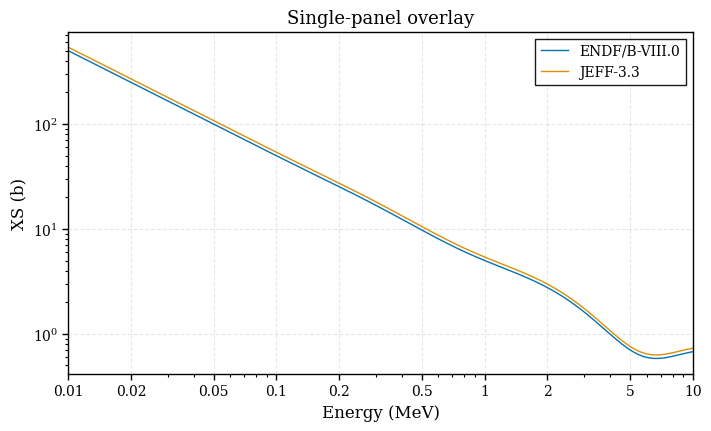

PASS — single-panel overlay


In [14]:
fig = (ComparisonBuilder(interpolation='log-log')
    .set_reference(ref_data)
    .add_comparison(cmp_data1)
    .set_labels(title='Single-panel overlay', x_label='Energy (MeV)', y_label='XS (b)')
    .set_scales(log_x=True, log_y=True)
    .set_legend(loc='best')
    .build())

assert len(fig.axes) == 1, 'Should have exactly 1 axis'
plt.show()
print('PASS — single-panel overlay')

### 3.2 Dual-panel — relative difference

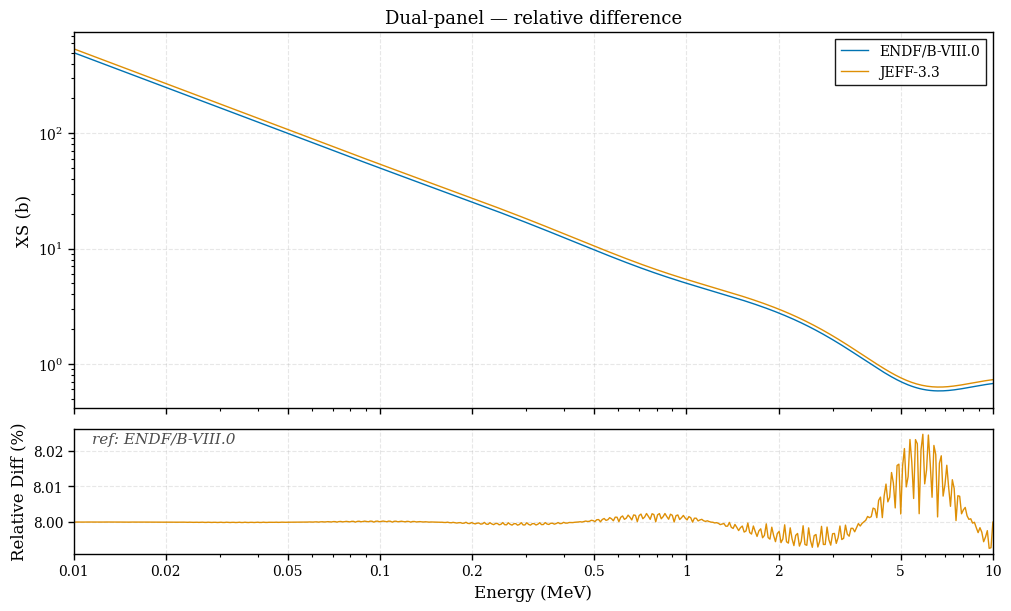

PASS — dual-panel with relative difference


In [15]:
fig = (ComparisonBuilder(interpolation='log-log')
    .set_reference(ref_data)
    .add_comparison(cmp_data1)
    .set_difference_panel(mode='relative')
    .set_labels(title='Dual-panel — relative difference', x_label='Energy (MeV)', y_label='XS (b)')
    .set_scales(log_x=True, log_y=True)
    .set_legend(loc='best')
    .build())

assert len(fig.axes) == 2, 'Should have 2 axes (main + diff)'
assert fig.axes[0].get_xlabel() == '', 'Top panel x-label should be hidden'
assert '%' in fig.axes[1].get_ylabel(), 'Diff panel should show %'
plt.show()
print('PASS — dual-panel with relative difference')

### 3.3 Dual-panel — absolute difference

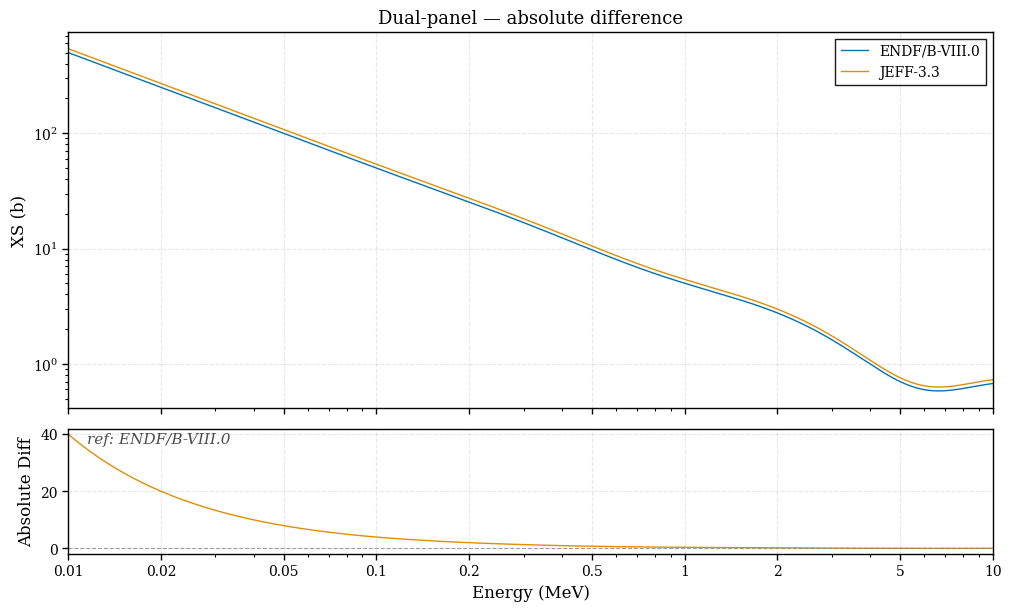

PASS — dual-panel with absolute difference


In [16]:
fig = (ComparisonBuilder(interpolation='log-log')
    .set_reference(ref_data)
    .add_comparison(cmp_data1)
    .set_difference_panel(mode='absolute')
    .set_labels(title='Dual-panel — absolute difference', x_label='Energy (MeV)', y_label='XS (b)')
    .set_scales(log_x=True, log_y=True)
    .build())

assert 'Absolute' in fig.axes[1].get_ylabel()
plt.show()
print('PASS — dual-panel with absolute difference')

### 3.4 Multiple comparisons

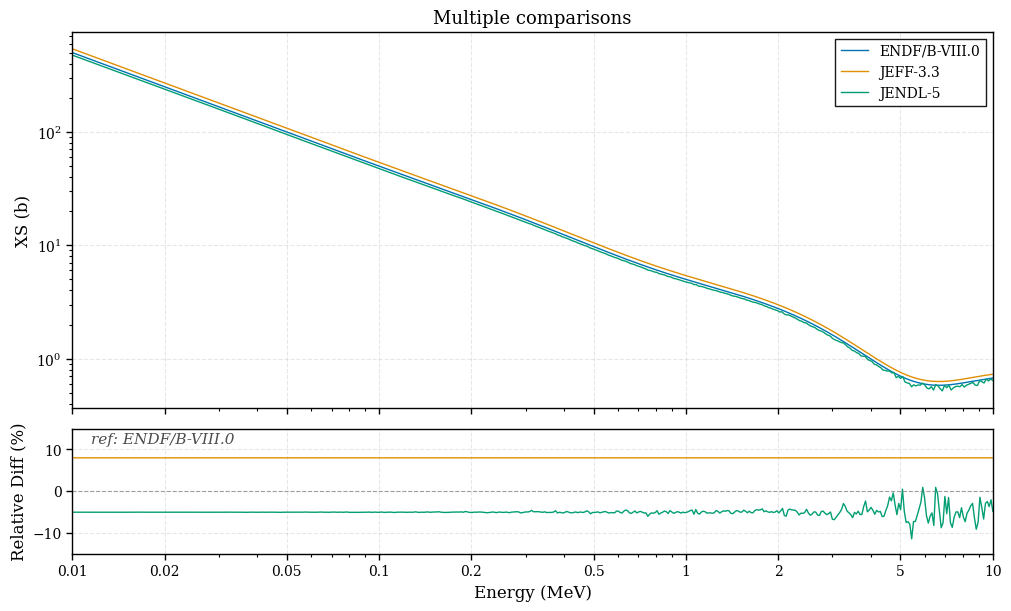

PASS — multiple comparisons with bounded diff panel


In [17]:
fig = (ComparisonBuilder(interpolation='log-log')
    .set_reference(ref_data)
    .add_comparison(cmp_data1)
    .add_comparison(cmp_data2)
    .set_difference_panel(mode='relative', y_lim=(-15, 15))
    .set_labels(title='Multiple comparisons', x_label='Energy (MeV)', y_label='XS (b)')
    .set_scales(log_x=True, log_y=True)
    .set_legend(loc='best')
    .build())

assert len(fig.axes) == 2
plt.show()
print('PASS — multiple comparisons with bounded diff panel')

### 3.5 Custom diff panel y-limits

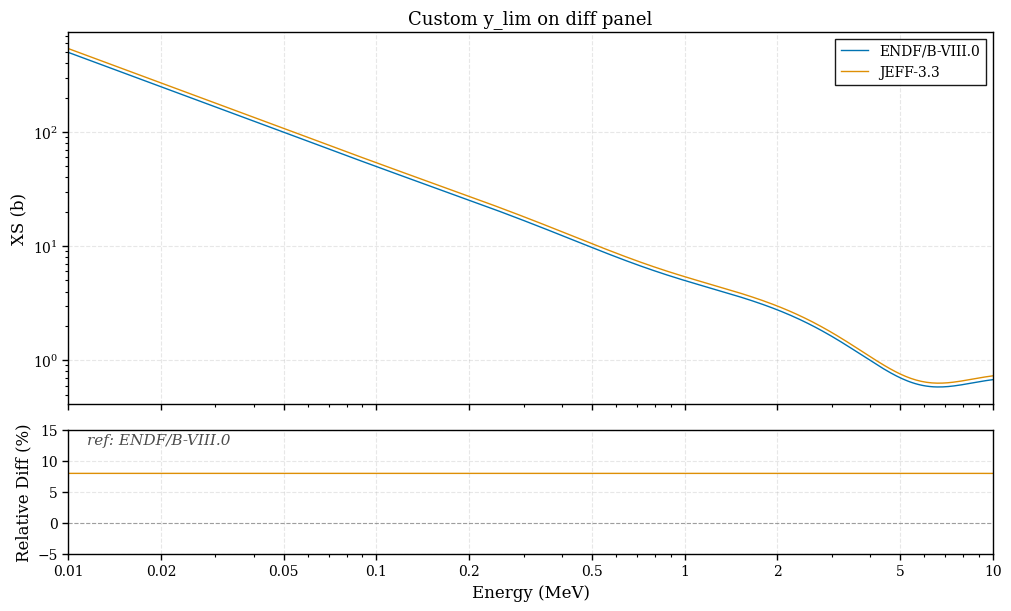

PASS — diff panel y_lim = (-5.0, 15.0)


In [18]:
fig = (ComparisonBuilder(interpolation='log-log')
    .set_reference(ref_data)
    .add_comparison(cmp_data1)
    .set_difference_panel(mode='relative', y_lim=(-5, 15))
    .set_labels(title='Custom y_lim on diff panel', x_label='Energy (MeV)', y_label='XS (b)')
    .set_scales(log_x=True, log_y=True)
    .build())

y_lo, y_hi = fig.axes[1].get_ylim()
assert abs(y_lo - (-5)) < 1 and abs(y_hi - 15) < 1, f'y_lim mismatch: ({y_lo}, {y_hi})'
plt.show()
print(f'PASS — diff panel y_lim = ({y_lo:.1f}, {y_hi:.1f})')

### 3.6 Method chaining returns self

In [19]:
builder = ComparisonBuilder()
assert builder.set_reference(ref_data) is builder
assert builder.add_comparison(cmp_data1) is builder
assert builder.set_difference_panel() is builder
assert builder.set_labels(title='T', x_label='X', y_label='Y') is builder
assert builder.set_scales(log_x=True) is builder
assert builder.set_limits(x_lim=(1, 10)) is builder
assert builder.set_legend(loc='upper left') is builder
assert builder.set_grid(grid=False) is builder
print('PASS — all fluent methods return builder instance')

PASS — all fluent methods return builder instance


### 3.7 Error handling

In [20]:
# No reference
try:
    ComparisonBuilder().add_comparison(cmp_data1).build()
    print('FAIL — should have raised ValueError (no reference)')
except ValueError as e:
    print(f'PASS — no reference: {e}')

# No comparisons
try:
    ComparisonBuilder().set_reference(ref_data).build()
    print('FAIL — should have raised ValueError (no comparisons)')
except ValueError as e:
    print(f'PASS — no comparisons: {e}')

PASS — no reference: No reference data set. Call set_reference() first.
PASS — no comparisons: No comparison data. Call add_comparison() at least once.


### 3.8 Linear data — lin-lin interpolation

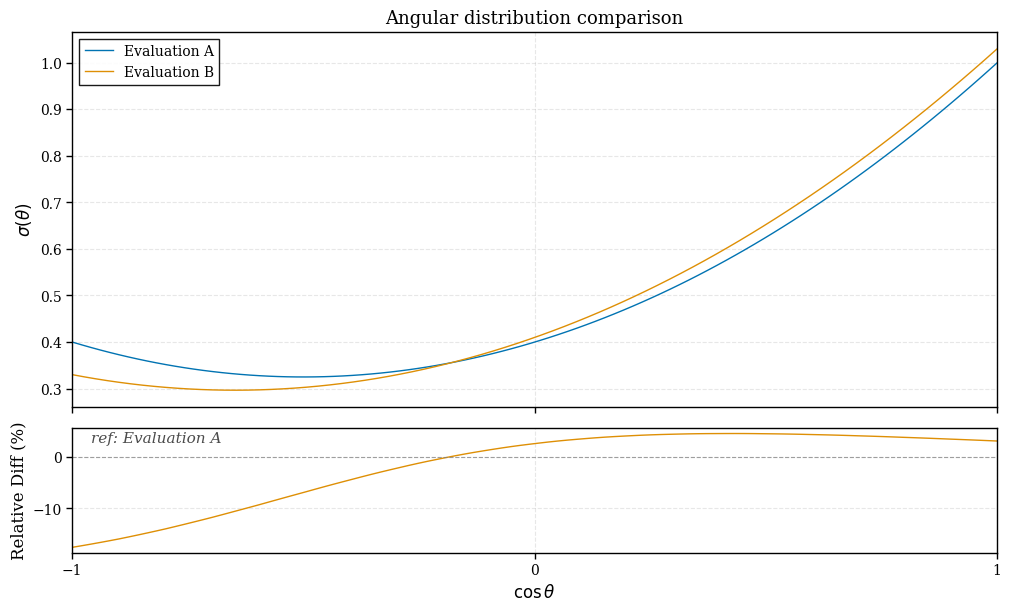

PASS — lin-lin comparison (angular distribution)


In [21]:
# Angular distribution style data (cosine axis)
x_r = np.linspace(-1, 1, 100)
x_c = np.linspace(-1, 1, 80)
y_r = 0.5 + 0.3 * x_r + 0.2 * (3 * x_r**2 - 1) / 2
y_c = 0.5 + 0.35 * x_c + 0.18 * (3 * x_c**2 - 1) / 2

ref_ad = PlotData(x=x_r, y=y_r, label='Evaluation A')
cmp_ad = PlotData(x=x_c, y=y_c, label='Evaluation B')

fig = (ComparisonBuilder(interpolation='lin-lin')
    .set_reference(ref_ad)
    .add_comparison(cmp_ad)
    .set_difference_panel(mode='relative')
    .set_labels(title='Angular distribution comparison',
                x_label=r'$\cos\theta$', y_label=r'$\sigma(\theta)$')
    .build())

plt.show()
print('PASS — lin-lin comparison (angular distribution)')

---
## 4. `DifferencePlotData` — dataclass checks

In [22]:
# Auto-generated label — relative
d_rel = DifferencePlotData(
    x=np.array([1., 2.]), y=np.array([0.1, 0.2]),
    difference_type='relative',
    reference_label='ENDF/B-VIII.0', comparison_label='JEFF-3.3',
)
assert 'JEFF-3.3' in d_rel.label and 'ENDF/B-VIII.0' in d_rel.label
assert '/' in d_rel.label  # relative format: (cmp − ref) / ref
print(f'PASS — relative label: "{d_rel.label}"')

# Auto-generated label — absolute
d_abs = DifferencePlotData(
    x=np.array([1., 2.]), y=np.array([1., 2.]),
    difference_type='absolute',
    reference_label='A', comparison_label='B',
)
assert '/' not in d_abs.label  # absolute: cmp − ref (no division)
print(f'PASS — absolute label: "{d_abs.label}"')

# Metadata
assert d_rel.metadata['difference_type'] == 'relative'
assert d_rel.metadata['reference_label'] == 'ENDF/B-VIII.0'
print('PASS — metadata stored correctly')

PASS — relative label: "(JEFF-3.3 − ENDF/B-VIII.0) / ENDF/B-VIII.0"
PASS — absolute label: "B − A"
PASS — metadata stored correctly


---
## 5. `compute_difference` — visual comparison

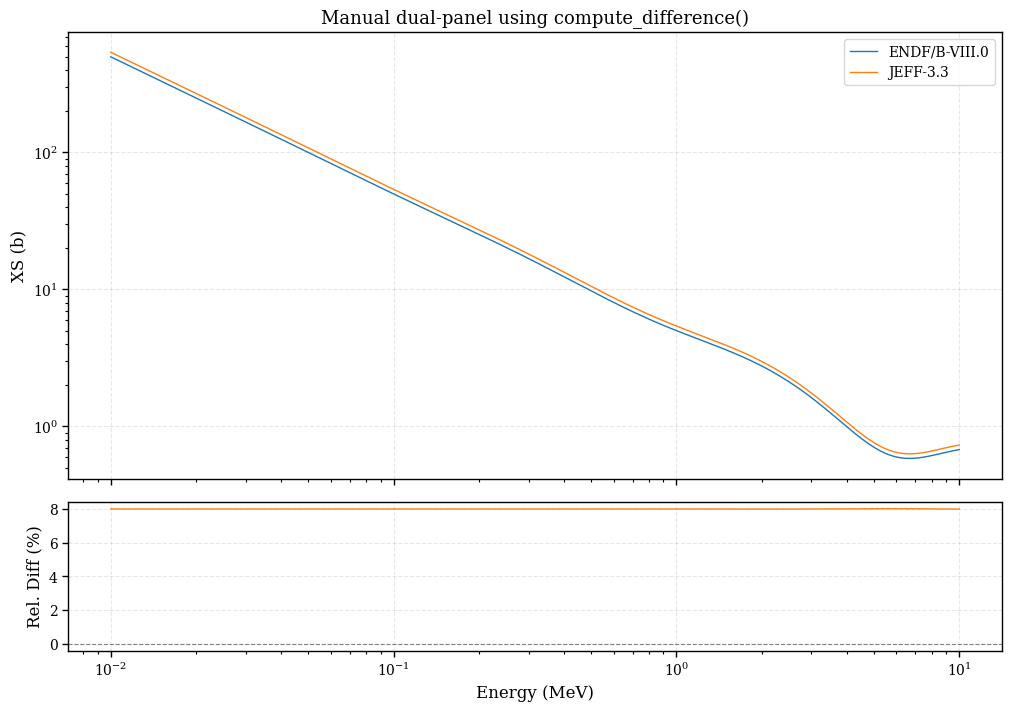

PASS — standalone compute_difference: 8.0 % mean diff


In [23]:
# Use compute_difference standalone, then plot with PlotBuilder
result = compute_difference(
    ref_data, cmp_data1, mode='relative',
    interpolation='log-log', grid='reference',
)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})

ax1.loglog(ref_data.x, ref_data.y, label=ref_data.label)
ax1.loglog(cmp_data1.x, cmp_data1.y, label=cmp_data1.label)
ax1.set_ylabel('XS (b)'); ax1.legend(); ax1.grid(True, alpha=0.3)
ax1.set_title('Manual dual-panel using compute_difference()')
ax1.tick_params(axis='x', labelbottom=False)

ax2.plot(result.common_x, result.difference.y, 'C1')
ax2.axhline(0, color='grey', ls='--', lw=0.8)
ax2.set_xscale('log')
ax2.set_xlabel('Energy (MeV)'); ax2.set_ylabel('Rel. Diff (%)')
ax2.grid(True, alpha=0.3)

plt.show()
print(f'PASS — standalone compute_difference: {result.difference.y.mean():.1f} % mean diff')

---
## Summary

In [24]:
print('All comparison plotting tests passed.')

All comparison plotting tests passed.


---
## 6. Real case: Fe-56 elastic scattering (MT=2) — three ACE libraries

In [25]:
import kika

# Load three ACE files (Windows paths mapped to WSL)
ace_1 = kika.read_ace('/mnt/c/Users/MONLEON-DE-LA-JAN/Documents/ACE_samples/260560_31.02c')
ace_2 = kika.read_ace('/mnt/c/Users/MONLEON-DE-LA-JAN/Documents/ACE_samples/26056.20c')
ace_3 = kika.read_ace('/mnt/c/Users/MONLEON-DE-LA-JAN/Documents/ACE_samples/260560_40.02c')

print(f'File 1: {ace_1.header.zaid}  —  {len(ace_1.energies)} energy points')
print(f'File 2: {ace_2.header.zaid}  —  {len(ace_2.energies)} energy points')
print(f'File 3: {ace_3.header.zaid}  —  {len(ace_3.energies)} energy points')

File 1: 26056  —  41241 energy points
File 2: 26056  —  71183 energy points
File 3: 26056  —  42541 energy points


In [26]:
# Extract elastic scattering (MT=2) as PlotData
xs_1 = ace_1.cross_section.to_plot_data(mt=2, label='260560_31.02c')
xs_2 = ace_2.cross_section.to_plot_data(mt=2, label='26056.20c')
xs_3 = ace_3.cross_section.to_plot_data(mt=2, label='260560_40.02c')

for xs in (xs_1, xs_2, xs_3):
    print(f'{xs.label}: {len(xs.x)} pts, E = [{xs.x[0]:.4e}, {xs.x[-1]:.4e}] MeV')
print(f'PlotData type: {type(xs_1).__name__}')  # CrossSectionPlotData → auto log-log

260560_31.02c: 41241 pts, E = [1.0000e-11, 2.0000e+02] MeV
26056.20c: 71183 pts, E = [1.0000e-11, 2.0000e+02] MeV
260560_40.02c: 42541 pts, E = [1.0000e-11, 1.5000e+02] MeV
PlotData type: CrossSectionPlotData


### 6.1 Difference-only panel (no overlay)

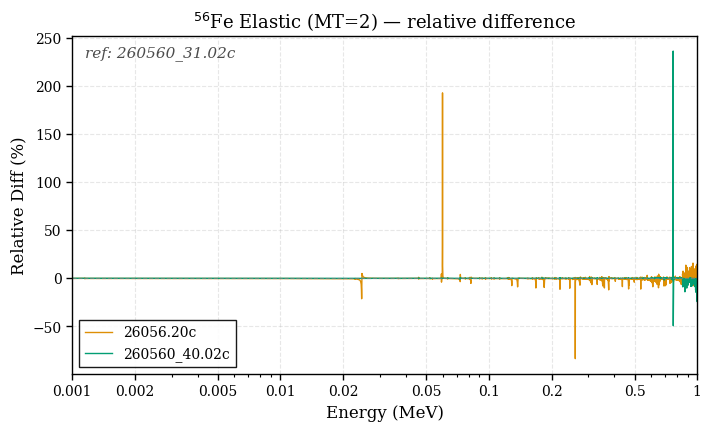

PASS — diff-only panel (3 ACE libraries)


In [27]:
# Diff-only: shows only the relative difference, no XS overlay
fig = (ComparisonBuilder()
    .set_reference(xs_1)
    .add_comparison(xs_2)
    .add_comparison(xs_3)
    .set_difference_panel(mode='relative', only=True)
    .set_labels(
        title=r'$^{56}$Fe Elastic (MT=2) — relative difference',
        x_label='Energy (MeV)',
    )
    .set_scales(log_x=True)
    .set_limits(x_lim=(1e-3, 1.0))
    .build())

assert len(fig.axes) == 1
plt.show()
print('PASS — diff-only panel (3 ACE libraries)')

### 6.2 Dual-panel comparison (3 libraries)

Diff panel x-limits: (1.0e+00, 1.0e+01)


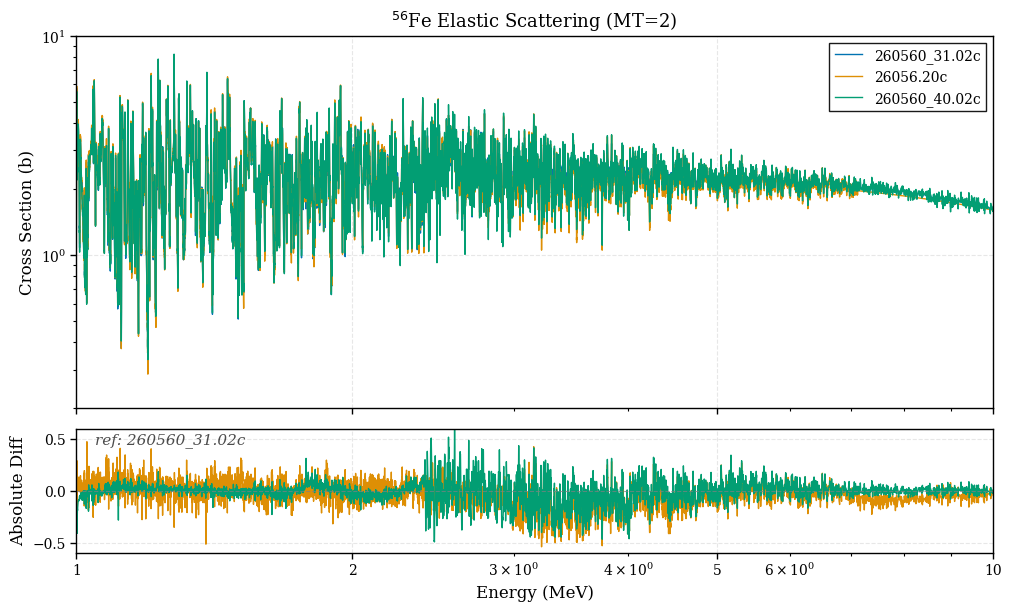

In [29]:
# Dual-panel: overlay on top, relative diff below, x clipped
fig = (ComparisonBuilder()
    .set_reference(xs_1)
    .add_comparison(xs_2)
    .add_comparison(xs_3)
    .set_difference_panel(mode='absolute')
    .set_labels(
        title=r'$^{56}$Fe Elastic Scattering (MT=2)',
        x_label='Energy (MeV)',
        y_label='Cross Section (b)',
    )
    .set_scales(log_x=True, log_y=True)
    .set_limits(x_lim=(1, 10.0), y_lim=(0.2, 10.0))
    .set_difference_panel(y_lim=(-0.6, 0.6))
    .set_legend(loc='best')
    .build())

# Verify x-limits propagate to both panels (sharex=True)
x_lo, x_hi = fig.axes[1].get_xlim()
print(f'Diff panel x-limits: ({x_lo:.1e}, {x_hi:.1e})')
plt.show()